In [1]:
from pathlib import Path
import os

# Find project root by folder name
cwd = Path(os.getcwd())

while cwd.name != "dfsc":
    cwd = cwd.parent

os.chdir(cwd)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\Devanshi\dfsc


In [2]:
# ============================================================
# CELL 1 — Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Import ALL functions used in this notebook from prophet_model
from src.models.prophet_model import (
    build_german_holidays_df,
    prepare_prophet_data,
    train_prophet_model,
    generate_forecast,
    calculate_metrics,
    plot_forecast,
)

from src.config import TRAIN_END_DATE, FORECAST_HORIZON_DAYS
from prophet.diagnostics import cross_validation, performance_metrics

print("All imports successful.")

All imports successful.


Running Prophet on 7 representative stores: [262, 817, 562, 1114, 251, 30, 811]

--- Store 262 ---
  Train: 702 days | Test: 212 days


20:08:50 - cmdstanpy - INFO - Chain [1] start processing
20:08:50 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 6.3% | MAE: €1,318 | WAPE: 6.3%


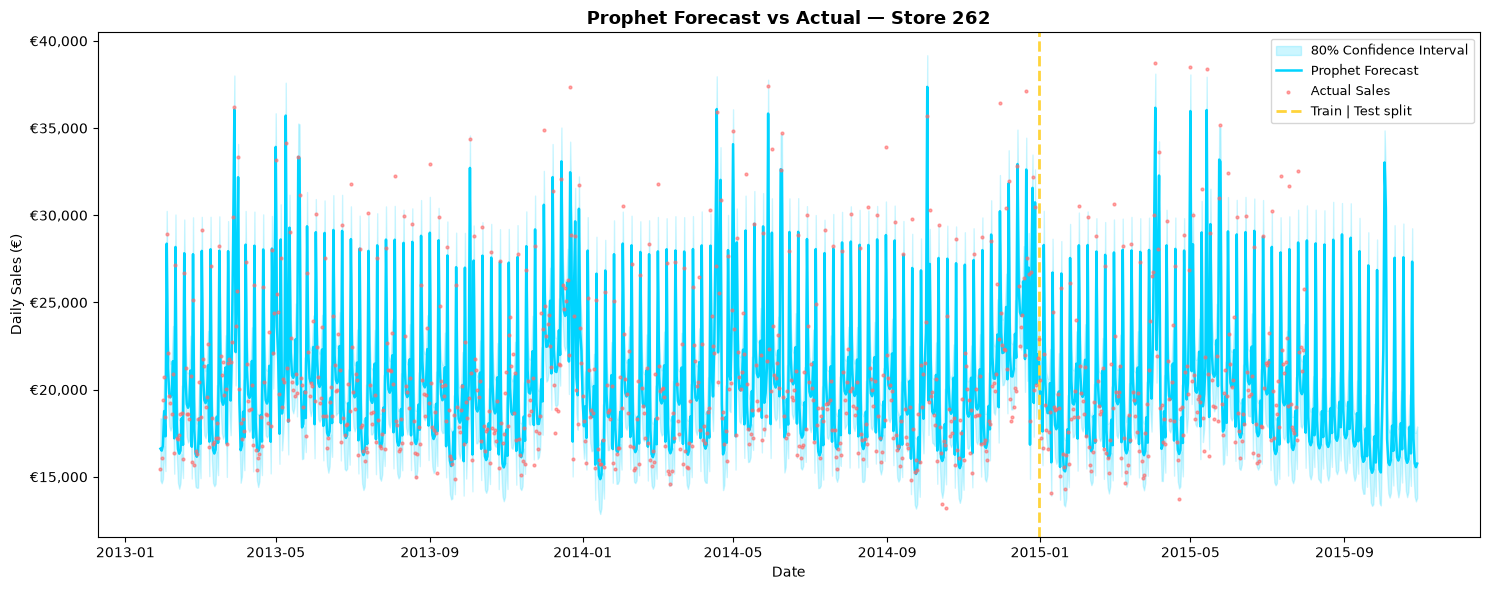

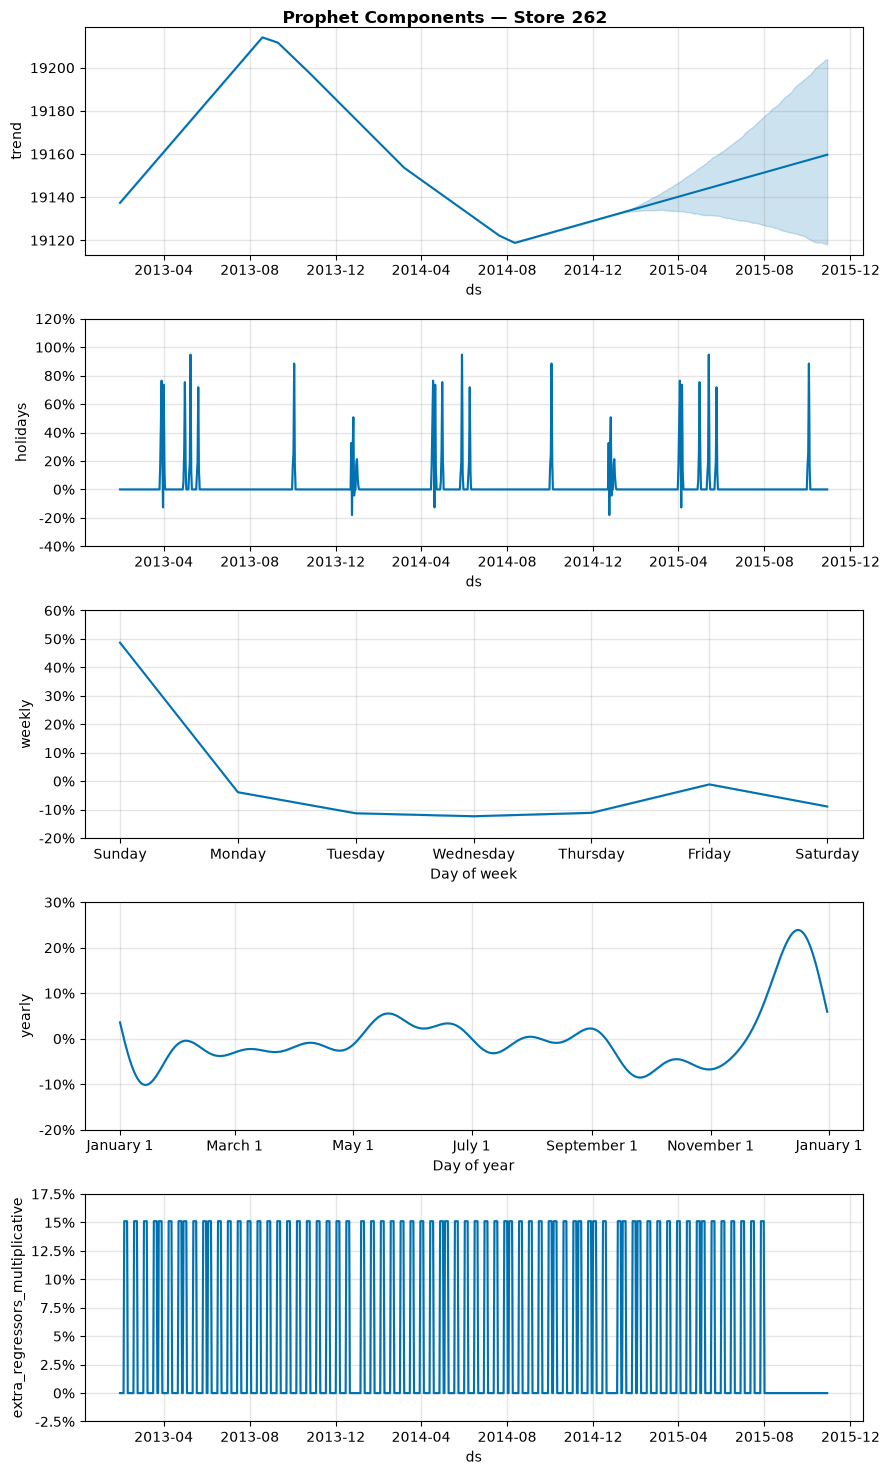

20:08:52 - cmdstanpy - INFO - Chain [1] start processing



--- Store 817 ---
  Train: 580 days | Test: 176 days


20:08:53 - cmdstanpy - INFO - Chain [1] done processing
20:08:53 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 7.0% | MAE: €1,304 | WAPE: 6.5%

--- Store 562 ---
  Train: 702 days | Test: 212 days


20:08:53 - cmdstanpy - INFO - Chain [1] done processing
20:08:54 - cmdstanpy - INFO - Chain [1] start processing


...

  MAPE: 7.4% | MAE: €1,450 | WAPE: 7.5%

--- Store 30 ---
  Train: 575 days | Test: 174 days


20:08:55 - cmdstanpy - INFO - Chain [1] done processing
20:08:55 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 12.6% | MAE: €535 | WAPE: 12.1%

--- Store 811 ---
  Train: 580 days | Test: 176 days


20:08:55 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 10.5% | MAE: €395 | WAPE: 9.8%

=== PROPHET ACCURACY RESULTS ===
        MAPE      MAE     RMSE   WAPE
Store                                
262     6.28  1318.37  1719.08   6.33
817     6.98  1304.45  1621.35   6.45
562     5.43  1006.44  1335.56   5.60
1114   10.30  2307.62  2819.04  10.66
251     7.42  1450.30  1884.45   7.49
30     12.57   534.93   685.25  12.12
811    10.53   395.05   517.03   9.84

Average MAPE across 7 stores: 8.5%


In [3]:
# ============================================================
# notebooks/03_prophet_forecasting.ipynb
# ============================================================

import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import importlib
import src.models.prophet_model as pm
importlib.reload(pm)
from src.models.prophet_model import plot_forecast
from src.config import FIGURES_DIR

from src.config import TRAIN_END_DATE, FORECAST_HORIZON_DAYS
from prophet.diagnostics import cross_validation, performance_metrics

# ---- Load processed data ----
train_df = pd.read_parquet("data/processed/train_features.parquet")
test_df  = pd.read_parquet("data/processed/test_features.parquet")

# Full dataset for preparing prophet format
full_df = pd.concat([train_df, test_df]).sort_values(["Store","Date"])

# ---- Select demonstration stores ----
# We run Prophet on the top 5 A-class stores + 1 representative B and C store.
# Running on all 1,115 stores is computationally intensive (~90 minutes).
# In a production deployment, this loop would run overnight as a batch job.
a_stores = (train_df[train_df["ABC_Class"]=="A"]
            .groupby("Store")["Sales"].sum()
            .nlargest(5).index.tolist())
b_store  = (train_df[train_df["ABC_Class"]=="B"]
            .groupby("Store")["Sales"].sum()
            .nlargest(1).index.tolist())
c_store  = (train_df[train_df["ABC_Class"]=="C"]
            .groupby("Store")["Sales"].sum()
            .nlargest(1).index.tolist())

demo_stores = a_stores + b_store + c_store
print(f"Running Prophet on {len(demo_stores)} representative stores: {demo_stores}")

# ---- Build holiday dataframe ----
years = list(full_df["Date"].dt.year.unique())
holiday_df = build_german_holidays_df(years)

# ---- Train and forecast loop ----
all_forecasts   = []
all_metrics     = []

for store_id in demo_stores:
    print(f"\n--- Store {store_id} ---")

    # Prepare Prophet-format data
    prophet_data = prepare_prophet_data(full_df, store_id)

    # Chronological split
    train_prophet = prophet_data[prophet_data["ds"] <= TRAIN_END_DATE]
    test_prophet  = prophet_data[prophet_data["ds"] >  TRAIN_END_DATE]

    print(f"  Train: {len(train_prophet)} days | Test: {len(test_prophet)} days")

    # Train model
    model = train_prophet_model(train_prophet, holiday_df)

    # Create future dataframe — covers the test period + 90-day forward forecast
    # We must include the Promo values for the future period
    future = model.make_future_dataframe(
        periods = len(test_prophet) + FORECAST_HORIZON_DAYS,
        freq    = "D"
    )
    # Merge promotion data onto the future dataframe
    promo_map = prophet_data.set_index("ds")[["Promo","Promo2Active"]]
    future = future.merge(promo_map, on="ds", how="left")
    future[["Promo","Promo2Active"]] = (future[["Promo","Promo2Active"]]
                                         .fillna(0).astype(int))

    # Generate forecast
    forecast = generate_forecast(model, future)

    # Evaluate on test period only
    test_forecast = forecast[forecast["ds"] > TRAIN_END_DATE].copy()
    test_actuals  = test_prophet.copy()

    # Align on common dates
    common = pd.merge(test_actuals[["ds","y"]], 
                      test_forecast[["ds","yhat","yhat_lower","yhat_upper"]],
                      on="ds")

    metrics = calculate_metrics(common["y"], common["yhat"])
    metrics["Store"] = store_id
    all_metrics.append(metrics)

    print(f"  MAPE: {metrics['MAPE']:.1f}% | MAE: €{metrics['MAE']:,.0f} "
          f"| WAPE: {metrics['WAPE']:.1f}%")

    # Plot for first store (to avoid too many charts in notebook)
    if store_id == demo_stores[0]:
        plot_forecast(forecast, prophet_data, store_id, TRAIN_END_DATE)

        # Plot components — THIS is what you show in interview
        # It breaks the forecast into trend, weekly, yearly, holiday effects
        fig_comp = model.plot_components(forecast)
        fig_comp.suptitle(f"Prophet Components — Store {store_id}",
                          fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/forecasts/prophet_components_{store_id}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    # Store forecast for export
    forecast["Store"] = store_id
    all_forecasts.append(forecast)

# ---- Results summary ----
metrics_df = pd.DataFrame(all_metrics).set_index("Store")
print("\n=== PROPHET ACCURACY RESULTS ===")
print(metrics_df.to_string())
print(f"\nAverage MAPE across {len(demo_stores)} stores: "
      f"{metrics_df['MAPE'].mean():.1f}%")

In [4]:
# ============================================================
# PROPHET CROSS-VALIDATION
# ============================================================
# Standard train/test split gives ONE estimate of accuracy.
# Prophet's cross-validation gives MULTIPLE estimates by simulating
# what would have happened if we had trained and predicted at
# different points in history.
#
# initial   = how much history to use for the first training window
# period    = how often to retrain (slide the window forward)
# horizon   = how far ahead each model predicts
#
# The result is a distribution of accuracy across many forecasting
# exercises — much more reliable than a single train/test split.
# ============================================================

# Run CV on the single best store for demonstration
best_store = metrics_df["MAPE"].idxmin()
print(f"Running cross-validation on Store {best_store} (best MAPE in demo set)")

# Re-train on that store
cv_data = prepare_prophet_data(full_df, best_store)
cv_train = cv_data[cv_data["ds"] <= TRAIN_END_DATE]
cv_model = train_prophet_model(cv_train, holiday_df)

# Cross-validate
# initial='365 days' : first model trained on 1 year of data
# period='90 days'   : retrain every 90 days
# horizon='90 days'  : predict 90 days ahead each time
df_cv = cross_validation(
    cv_model,
    initial ="365 days",
    period  ="90 days",
    horizon ="90 days",
    parallel="processes"
)

df_perf = performance_metrics(df_cv)

print("\nCross-validation performance metrics:")
print(df_perf[["horizon","mape","mae","rmse"]].to_string())

avg_cv_mape = df_perf["mape"].mean() * 100
print(f"\nAverage CV MAPE: {avg_cv_mape:.1f}%")
print("""
Why CV MAPE matters more than single test-set MAPE:
The single test set MAPE could be misleadingly good or bad depending on
whether that particular 6-month period was easy or hard to forecast.
Cross-validation averages over many such periods — it tells us the
EXPECTED accuracy of the model in production, not just on one test window.
Report the CV MAPE in your consulting report, not the single-split MAPE.
""")

# Save Prophet forecasts for Power BI
forecast_export = pd.concat(all_forecasts)[
    ["Store","ds","yhat","yhat_lower","yhat_upper"]]
forecast_export.columns = ["Store","Date","Forecast","Lower_CI","Upper_CI"]
forecast_export.to_csv("outputs/powerbi/pb_forecast_actuals.csv", index=False)
print("Prophet forecasts saved for Power BI.")

20:09:11 - cmdstanpy - INFO - Chain [1] start processing


Running cross-validation on Store 562 (best MAPE in demo set)


20:09:11 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.



Cross-validation performance metrics:
   horizon      mape          mae         rmse
0   9 days  0.037827   660.642570   849.940726
1  10 days  0.039789   704.519309   894.801836
2  11 days  0.036668   658.924283   841.372388
3  12 days  0.041361   763.394578  1046.757698
4  13 days  0.040094   739.141666  1033.686474
5  14 days  0.045519   827.793183  1106.207898
6  15 days  0.048158   865.718898  1130.943322
7  16 days  0.051470   918.350315  1151.206340
8  17 days  0.049701   895.480979  1131.525050
9  18 days  0.048097   857.162401  1077.744555
10 19 days  0.044876   784.001353  1021.238802
11 20 days  0.045849   794.392846  1028.247689
12 21 days  0.042736   710.512960   841.723743
13 22 days  0.041068   683.057049   817.079169
14 23 days  0.038723   655.819169   792.201200
15 24 days  0.037854   665.235102   800.519214
16 25 days  0.033491   604.164195   744.941195
17 26 days  0.037556   697.160883   903.376842
18 27 days  0.049675   941.640186  1295.367280
19 28 days  0.054165 